In [1]:
import sys
import os

# Adds the parent directory of 'scripts' to the Python path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import pymc as pm
import arviz as az

from statsmodels.tsa.stattools import adfuller

from scripts.utils import (
    load_price_data,
    load_event_data,
    calculate_log_returns,
    plot_price_series,
    plot_log_returns
)

from scripts.bayesian_model import BayesianChangePointModel

plt.style.use("ggplot")

RANDOM_SEED = 42

In [2]:
prices = load_price_data("../Data/BrentOilPrices.csv")

events = load_event_data("../Data/oil_market_events.csv")
prices.head()
events.head()

,event_id,start_date,end_date,event_name,category,description,expected_direction
0,1,1990-08-02,1991-02-28,Iraq invasion of Kuwait / Gulf War,Geopolitical conflict,Iraq's invasion of Kuwait removed a large shar...,Increase then reversal
1,2,1997-07-02,1998-12-31,Asian Financial Crisis and 1998 price collapse,Economic shock,The Thai baht devaluation triggered a wider As...,Decrease
2,3,2001-09-11,2001-10-31,September 11 terrorist attacks,Geopolitical shock,The attacks on the United States created short...,Decrease
3,4,2003-03-20,2003-05-01,US-led invasion of Iraq,Geopolitical conflict,The invasion raised concerns about Middle East...,Increase
4,5,2005-08-29,2005-10-15,Hurricane Katrina,Supply disruption,Hurricane Katrina and the following Hurricane ...,Increase


In [3]:
print("Price Dataset Shape:", prices.shape)

print("Event Dataset Shape:", events.shape)

Price Dataset Shape: (9011, 2)
Event Dataset Shape: (15, 7)


In [4]:
prices.isnull().sum()

events.isnull().sum()

event_id              0
start_date            0
end_date              0
event_name            0
category              0
description           0
expected_direction    0
dtype: int64

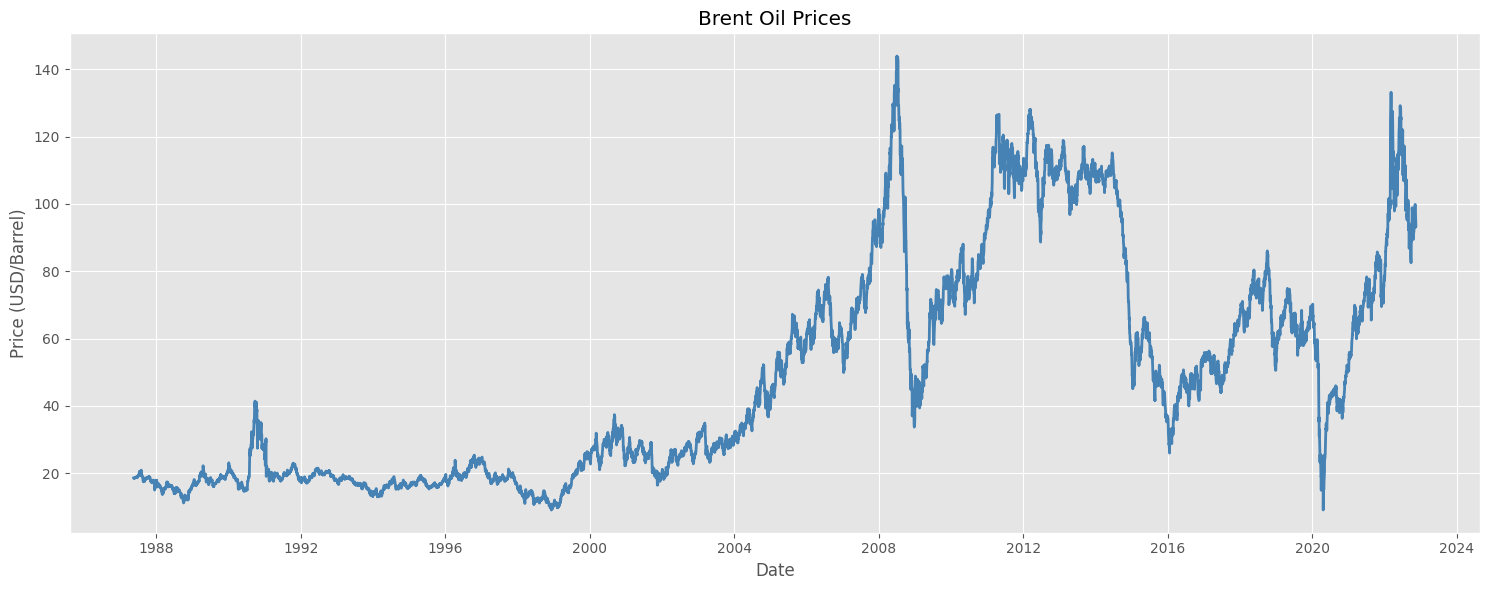

In [5]:
plot_price_series(prices)

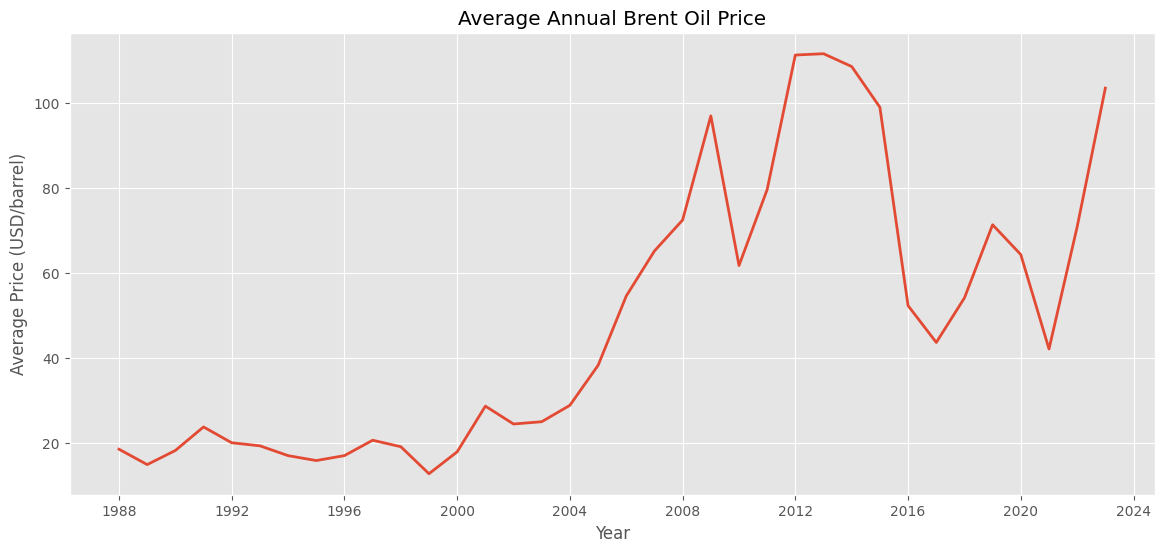

In [6]:
yearly = (
    prices
    .set_index("Date")
    .resample("YE")["Price"]
    .mean()
)

plt.figure(figsize=(14,6))

plt.plot(
    yearly.index,
    yearly.values,
    linewidth=2
)

plt.title("Average Annual Brent Oil Price")

plt.xlabel("Year")

plt.ylabel("Average Price (USD/barrel)")

plt.grid(True)

plt.show()

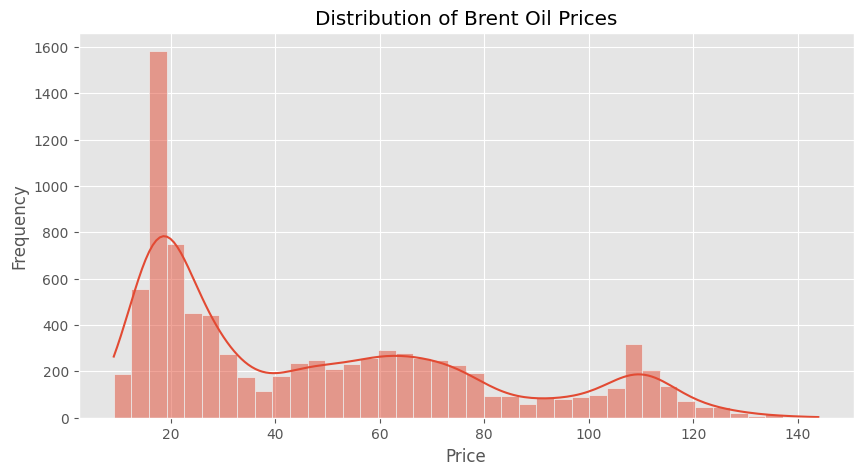

In [7]:
plt.figure(figsize=(10,5))

sns.histplot(
    prices["Price"],
    bins=40,
    kde=True
)

plt.title("Distribution of Brent Oil Prices")

plt.xlabel("Price")

plt.ylabel("Frequency")

plt.show()

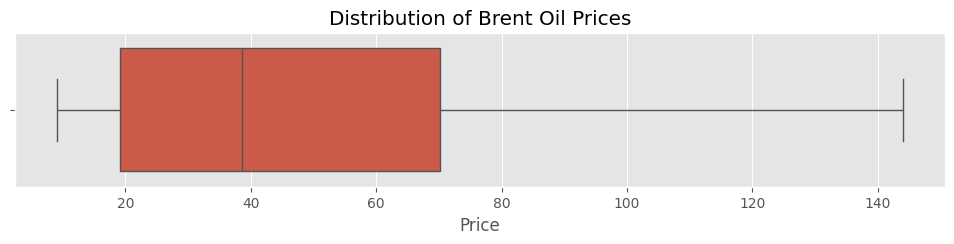

In [8]:
plt.figure(figsize=(12,2))

sns.boxplot(
    x=prices["Price"]
)

plt.title("Distribution of Brent Oil Prices")

plt.show()

In [9]:
events[
    [
        "start_date",
        "event_name",
        "category",
        "expected_direction"
    ]
]

,start_date,event_name,category,expected_direction
0,1990-08-02,Iraq invasion of Kuwait / Gulf War,Geopolitical conflict,Increase then reversal
1,1997-07-02,Asian Financial Crisis and 1998 price collapse,Economic shock,Decrease
2,2001-09-11,September 11 terrorist attacks,Geopolitical shock,Decrease
3,2003-03-20,US-led invasion of Iraq,Geopolitical conflict,Increase
4,2005-08-29,Hurricane Katrina,Supply disruption,Increase
5,2008-07-11,Brent record peak (~USD 147/bbl),Market/demand cycle,Peak
6,2008-09-15,Global Financial Crisis (Lehman Brothers colla...,Economic shock,Decrease
7,2011-02-15,Arab Spring and Libyan Civil War,Geopolitical conflict,Increase
8,2014-11-27,OPEC maintains output amid US shale boom (2014...,OPEC policy / market share,Decrease
9,2016-11-30,First OPEC+ production cut agreement,OPEC policy,Increase


In [10]:
# Calculate log returns
returns = calculate_log_returns(prices)

returns.head()

,Date,Price,Log_Return
1,1987-05-21,18.45,-0.009709
2,1987-05-22,18.55,0.005405
3,1987-05-25,18.60,0.002692
4,1987-05-26,18.63,0.001612
5,1987-05-27,18.60,-0.001612


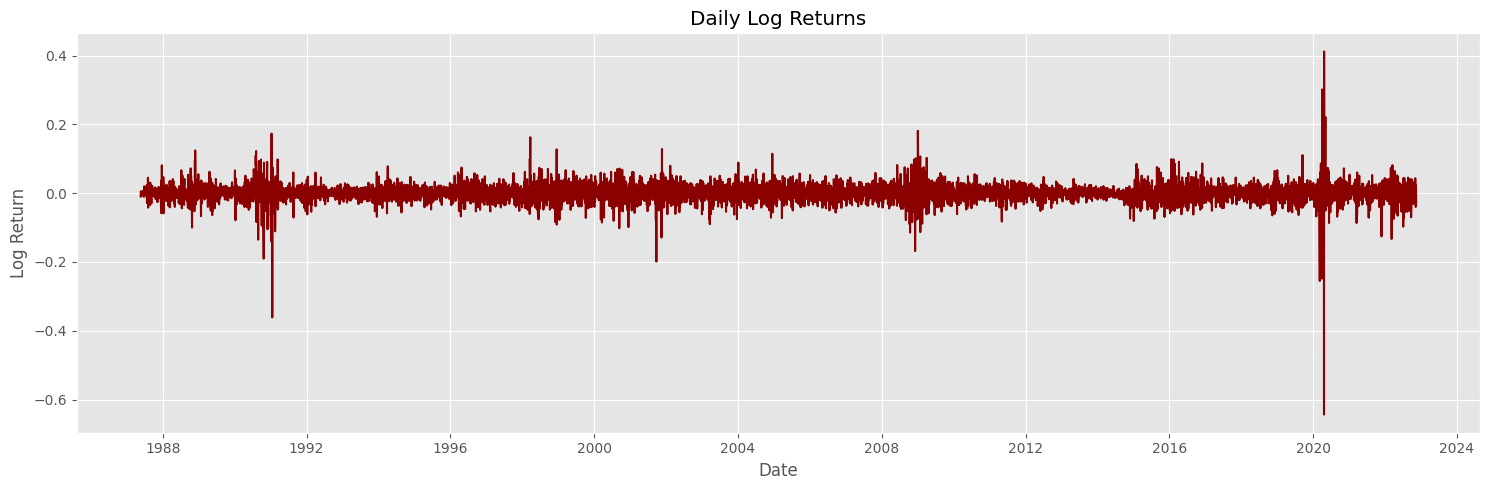

In [11]:
plot_log_returns(returns)

In [12]:
returns["Log_Return"].describe()

count    9010.000000
mean        0.000179
std         0.025532
min        -0.643699
25%        -0.011154
50%         0.000402
75%         0.012127
max         0.412023
Name: Log_Return, dtype: float64

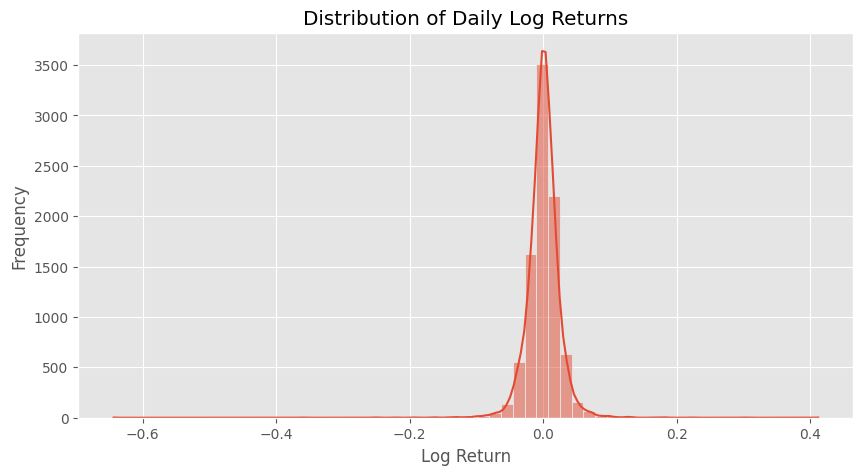

In [13]:
plt.figure(figsize=(10,5))

sns.histplot(
    returns["Log_Return"],
    bins=60,
    kde=True
)

plt.title("Distribution of Daily Log Returns")

plt.xlabel("Log Return")

plt.ylabel("Frequency")

plt.show()

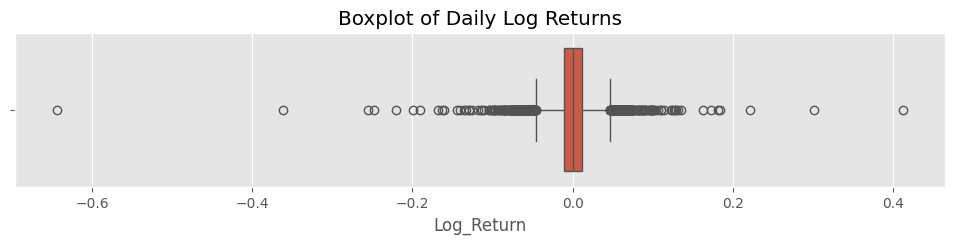

In [14]:
plt.figure(figsize=(12,2))

sns.boxplot(
    x=returns["Log_Return"]
)

plt.title("Boxplot of Daily Log Returns")

plt.show()

In [15]:
adf_result = adfuller(returns["Log_Return"])

print("ADF Statistic :", adf_result[0])
print("p-value       :", adf_result[1])

print("\nCritical Values")

for key, value in adf_result[4].items():
    print(f"{key}: {value:.4f}")

ADF Statistic : -16.4271134944858
p-value       : 2.4985801611433715e-29

Critical Values
1%: -3.4311
5%: -2.8619
10%: -2.5669


In [16]:
if adf_result[1] < 0.05:
    print("✓ Log returns are stationary.")
else:
    print("✗ Log returns are not stationary.")

✓ Log returns are stationary.


In [17]:
returns["Rolling_Volatility"] = (
    returns["Log_Return"]
    .rolling(window=30)
    .std()
)

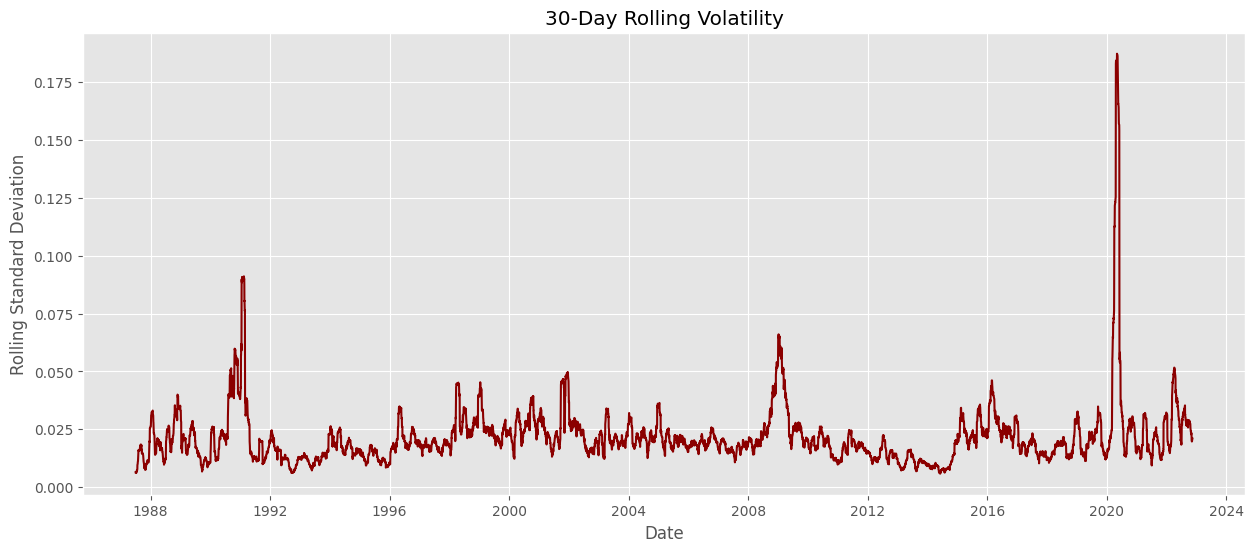

In [18]:
plt.figure(figsize=(15,6))

plt.plot(
    returns["Date"],
    returns["Rolling_Volatility"],
    color="darkred"
)

plt.title("30-Day Rolling Volatility")

plt.xlabel("Date")

plt.ylabel("Rolling Standard Deviation")

plt.grid(True)

plt.show()

In [19]:
returns["Rolling_Mean"] = (
    returns["Log_Return"]
    .rolling(window=30)
    .mean()
)

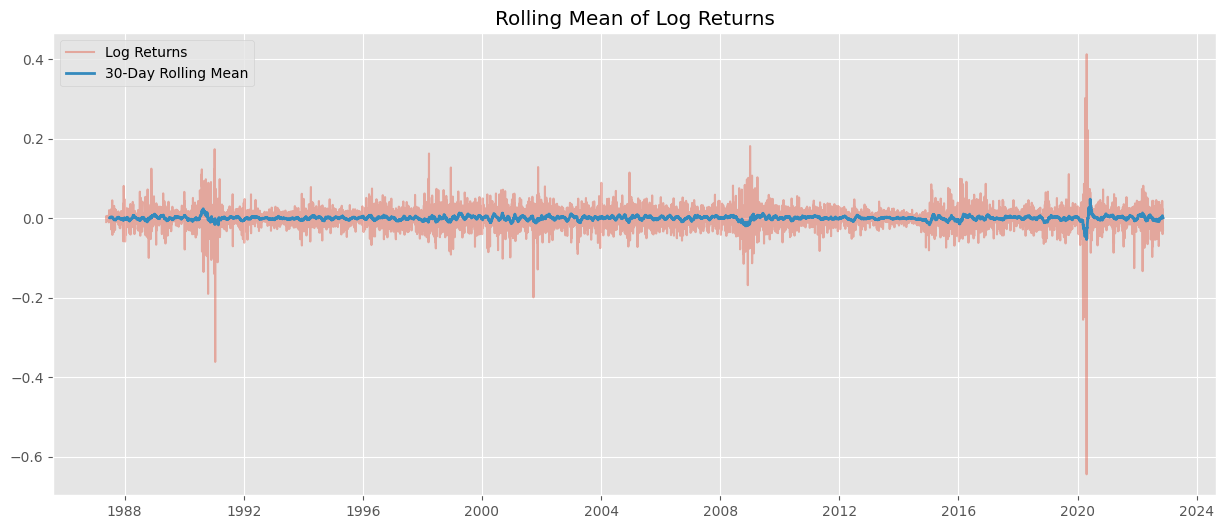

In [20]:
plt.figure(figsize=(15,6))

plt.plot(
    returns["Date"],
    returns["Log_Return"],
    alpha=0.4,
    label="Log Returns"
)

plt.plot(
    returns["Date"],
    returns["Rolling_Mean"],
    linewidth=2,
    label="30-Day Rolling Mean"
)

plt.legend()

plt.title("Rolling Mean of Log Returns")

plt.show()

In [21]:
# Use raw prices for the Bayesian change point model
price_series = prices["Price"].values

# Time index
time_index = np.arange(len(price_series))

print(f"Number of observations: {len(price_series)}")

Number of observations: 9011


In [22]:
model = BayesianChangePointModel(price_series)

model.build_model()

print("Bayesian model successfully created.")

Bayesian model successfully created.


In [23]:
model.model

  tau ~ DiscreteUniform(<constant>, <constant>)
  mu1 ~ Normal(48.4, 65.7)
  mu2 ~ Normal(48.4, 65.7)
sigma ~ HalfNormal(0, 32.9)
  obs ~ Normal(f(mu1, mu2, tau), sigma)

In [24]:
trace = model.sample(
    draws=2000,
    tune=1000,
    chains=4,
    target_accept=0.95
)

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu1, mu2, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 9 seconds.


In [25]:
summary = model.summary()

summary

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
tau,4520.8,3.2,4500,4500,1759,1695,1.00,0.076,0.056
mu1,21.42,0.274,21,22,6951,5352,1.00,0.0033,0.0024
mu2,75.604,0.278,75,76,7200,5520,1.00,0.0033,0.0022
sigma,18.598,0.137,18,19,7734,5588,1.00,0.0016,0.0011


In [26]:
summary["r_hat"] = pd.to_numeric(summary["r_hat"])

(summary["r_hat"] <= 1.01).all()

np.True_

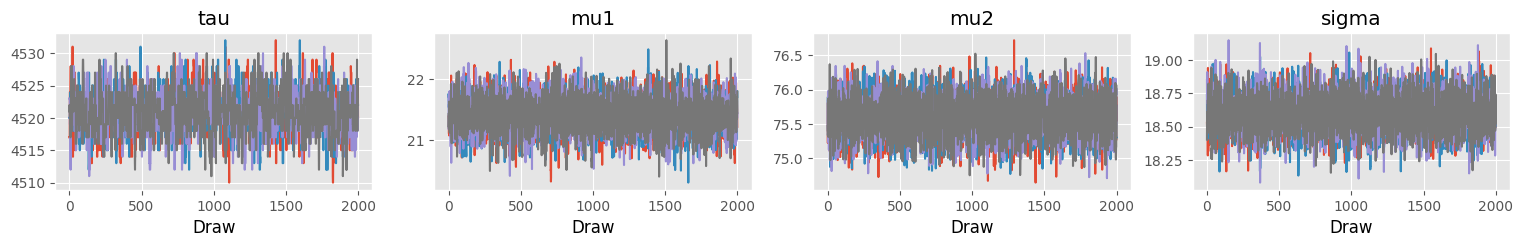

In [27]:
model.plot_trace()

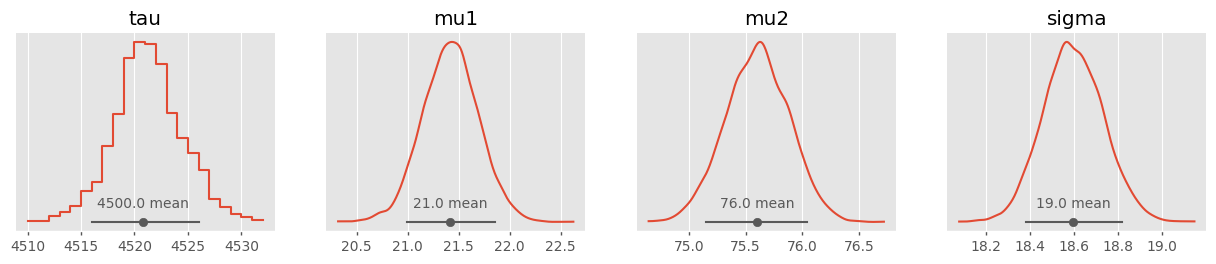

In [28]:
model.plot_posterior()

In [29]:
params = model.get_parameters()

params

{'tau': 4520,
 'mu1': 21.419696874851475,
 'mu2': 75.60430098996733,
 'sigma': 18.597879360469484}

In [30]:
change_index = model.get_change_point()

change_date = prices.iloc[change_index]["Date"]

print(change_date)

2005-02-23 00:00:00


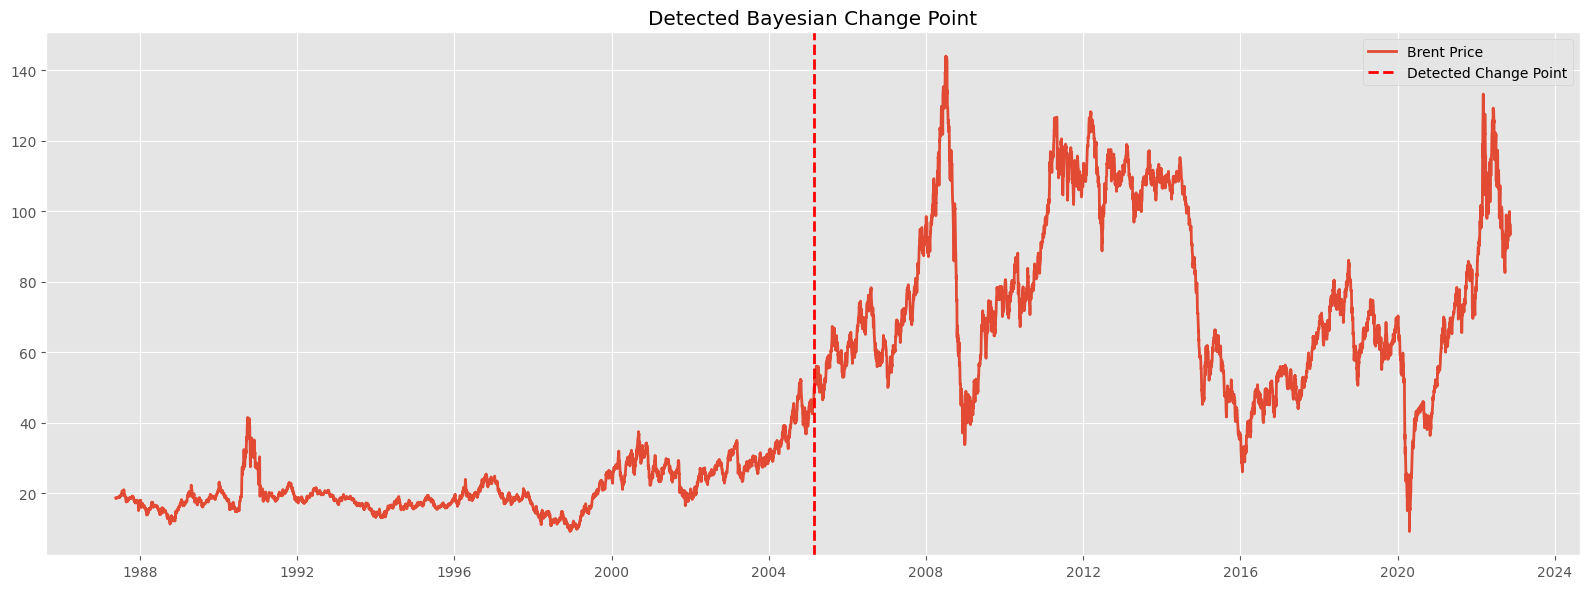

In [31]:
from scripts.utils import plot_change_point

plot_change_point(
    prices,
    change_index
)

In [32]:
pct = model.percent_change()

print(f"Average price changed by {pct:.2f}%")

Average price changed by 252.97%


In [33]:
from scripts.utils import generate_report

report = generate_report(
    change_date,
    params["mu1"],
    params["mu2"],
    events
)

pd.DataFrame([report])

,Detected Change Point,Nearest Event,Category,Average Before,Average After,Percentage Change,Expected Direction
0,2005-02-23,Hurricane Katrina,Supply disruption,21.42,75.6,252.97,Increase


In [34]:
model.report()

Bayesian Change Point Report
Change Point Index : 4520
Mean Before        : 21.42
Mean After         : 75.60
Std Dev            : 18.60
Percentage Change  : 252.97%
